In [10]:
using PyPlot
import PhysicalConstants.CODATA2018: c_0, ħ
using Unitful
using OrdinaryDiffEq

In [11]:
""" Nromalised density along the vertical axis """
function vertical_density_norm(Nz, z)
    return Nz*exp.(-z.^2 ./2) / sqrt(2π)
end

""" Derivative of the incident laser beam taking into account the absorption of the independant atoms for a gaussian density, but not the SE """
function deriv_Iinc_no_SE_norm(du, u, p, t)
    Nz, γ, Isat = p
    du[1] = -vertical_density_norm(Nz, t) * 1 / (Isat*(1 +1/u[1]))
end

deriv_Iinc_no_SE_norm

In [12]:
N_atoms_z = 5e3
γ = 32.7e6 # In Hz
λ = 421e-9
ω0 = 2π*ustrip(c_0)/λ
sat = [0:100;]
Isat = ustrip(ħ)*γ*ω0^3 / (12π*ustrip(c_0)^2)
dz = 1e-2
z_range = [-5:dz:5;];

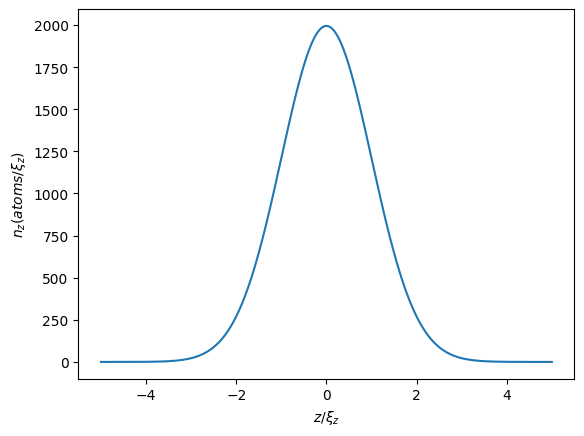

In [13]:
close("all")
fig = subplots()

plot(z_range, vertical_density_norm(N_atoms_z, z_range))
xlabel(L"z/\xi_z")
ylabel(L"$n_z (atoms/\xi_z)$")

pygui(false); gcf()

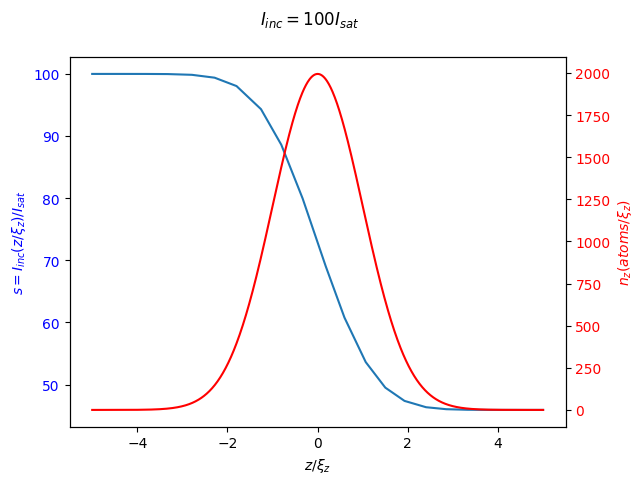

In [14]:
u0 = [sat[end]]
p = [N_atoms_z, γ, Isat]
prob = ODEProblem(deriv_Iinc_no_SE_norm, u0, (z_range[1], z_range[end]), p)
sol = solve(prob, reltol = 1e-8, abstol = 1e-8);

close("all")
fig, ax = subplots()

ax.plot(sol.t, sol.u)
ax.set_ylabel(L"$s=I_{inc}(z/\xi_z)/I_{sat}$", color="b")
ax.tick_params(axis="y", labelcolor="b")

ax2 = ax.twinx()
ax2.plot(z_range, vertical_density_norm(N_atoms_z, z_range), color="r")
ax2.set_ylabel(L"$n_z (atoms/\xi_z)$", color="r")
ax2.tick_params(axis="y", labelcolor="r")

ax.set_xlabel(L"$z/\xi_z$")

suptitle(L"I_{inc} = "*"$(u0[1])"*L" I_{sat}")

pygui(false); gcf()
# pygui(true); show()

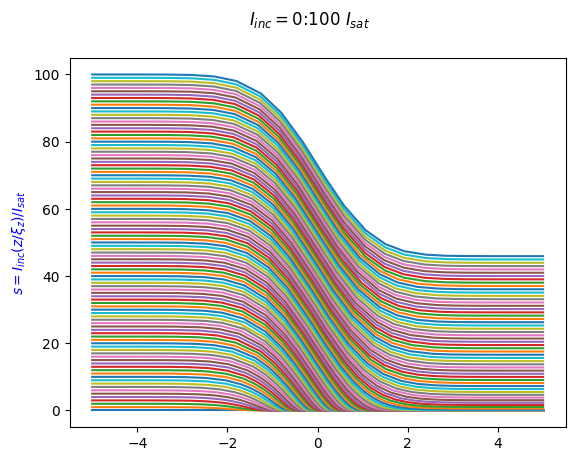

In [15]:
close("all")
fig, ax = subplots()

for (i, s) in enumerate(sat)
    p = [N_atoms_z, γ, Isat]
    prob = ODEProblem(deriv_Iinc_no_SE_norm, [s], (z_range[1], z_range[end]), p)
    sol = solve(prob, reltol = 1e-8, abstol = 1e-8)

    ax.plot(sol.t, sol.u)
end

ax.set_ylabel(L"$s=I_{inc}(z/\xi_z)/I_{sat}$", color="b")
# ax.tick_params(axis="y", labelcolor="b")

# ax2 = ax.twinx()
# ax2.plot(z_range, vertical_density_norm(N_atoms_z, z_range), color="r")
# ax2.set_ylabel(L"$n_z (atoms/\xi_z)$", color="r")
# ax2.tick_params(axis="y", labelcolor="r")

# ax.set_xlabel(L"$z/\xi_z$")

suptitle(L"I_{inc} = "*"$(sat[1]):$(sat[end]) "*L"I_{sat}")

pygui(false); gcf()
# pygui(true); show()

In [16]:
p = [N_atoms_z, γ, Isat]
Γ_SE_droplet = zeros(length(sat))

for (i, s) in enumerate(sat)
    prob = ODEProblem(deriv_Iinc_no_SE_norm, [s], (z_range[1], z_range[end]), p)
    sol = solve(prob, reltol = 1e-8, abstol = 1e-8, saveat=z_range)
    sat_i = [s[1] for s in sol.u]

    Γ_SE_droplet[i] = sum(dz .* vertical_density_norm(N_atoms_z, z_range) .* γ ./ (1 .+ 1 ./sat_i))
end


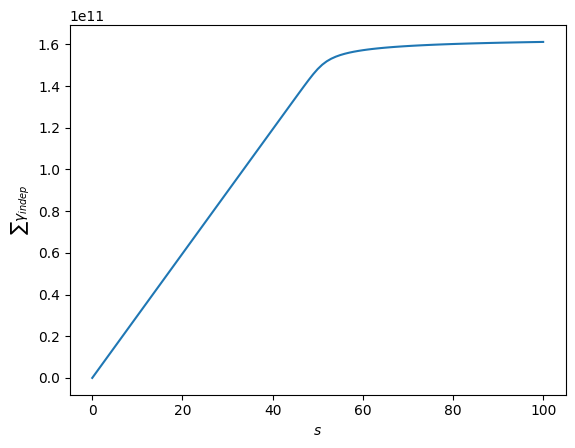

In [20]:
close("all")
plot(Γ_SE_droplet)
xlabel(L"s")
ylabel(L"\sum\gamma_{indep}")
gcf()